# 14 XGBoost + Residual TCN

This notebook tests a hybrid idea: let `XGBoost` do the heavy tabular forecasting first, then train a small `TCN` only on the **remaining residual error**.

The goal is simple:

- keep the strong nonlinear tabular fit from XGBoost,
- add a sequence model only where there may still be local timing structure,
- and check whether the hybrid improves 2025 volatility forecasts without losing stability.

## Why this hybrid

The earlier results suggest two things:

- `XGBoost` is still the strongest overall standalone model,
- sequence models often seem to know something about the local volatility shape, but they are not strong enough to replace XGBoost by themselves.

So the hybrid asks a cleaner question: **can a small temporal model improve the part XGBoost misses?**

In [1]:
from pathlib import Path
import copy
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor

os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

PROJECT_DIR = Path('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project')
DATA_DIR = PROJECT_DIR / 'data'
FIGURE_DIR = PROJECT_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DF_PATH = DATA_DIR / 'model_df_2016_2025.csv.gz'

try:
    mpl_dir = PROJECT_DIR / '.matplotlib'
    mpl_dir.mkdir(exist_ok=True)
except PermissionError:
    mpl_dir = Path('/tmp/erdos_vol_pred_runtime/.matplotlib')
    mpl_dir.mkdir(parents=True, exist_ok=True)

os.environ['MPLCONFIGDIR'] = str(mpl_dir)

assert MODEL_DF_PATH.exists(), f'Run 01_data_download_and_features.ipynb first: {MODEL_DF_PATH}'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

DEVICE

device(type='mps')

## Shared data, feature sets, and fixed model choices

To keep the experiment disciplined:

- the `XGBoost` stage uses the same rich tabular feature family as notebook 04,
- the residual `TCN` stage uses the same fast sequence feature family as notebook 13,
- the XGBoost hyperparameters are fixed at the best configuration already found earlier.

That way this notebook changes the modeling structure, not the whole feature-engineering story.

In [2]:
model_df = pd.read_csv(MODEL_DF_PATH, parse_dates=['Date']).sort_values(['Ticker', 'Date']).reset_index(drop=True)

stock_feature_columns = [
    'abs_return', 'squared_return', 'high_low_log_range', 'log_volume',
    'hist_vol_5d', 'hist_vol_10d', 'hist_vol_21d', 'hist_vol_63d',
    'realized_vol_5d', 'realized_vol_10d', 'realized_vol_21d', 'realized_vol_63d',
    'volume_zscore_5d', 'volume_zscore_10d', 'volume_zscore_21d', 'volume_zscore_63d',
    'return_mean_5d', 'return_mean_21d',
    'abs_return_mean_5d', 'abs_return_mean_21d',
    'parkinson_vol_5d', 'parkinson_vol_21d',
]
dynamic_proxy_columns = [
    col for col in model_df.columns
    if (col.startswith('mkt_') or col.startswith('macro_')) and not col.endswith('_proxy_level')
]
xgb_numeric_features = stock_feature_columns + dynamic_proxy_columns

fast_current_features = [
    'abs_return', 'squared_return', 'high_low_log_range', 'log_volume',
    'realized_vol_5d', 'realized_vol_21d', 'realized_vol_63d',
    'hist_vol_5d', 'hist_vol_21d',
    'volume_zscore_21d', 'abs_return_mean_5d', 'parkinson_vol_5d',
    'mkt_SPY_proxy_return', 'mkt_SPY_proxy_hist_vol_5d',
    'mkt_QQQ_proxy_return', 'mkt_QQQ_proxy_hist_vol_21d',
    'mkt_IWM_proxy_return',
    'macro_^VIX_proxy_level_zscore_21d', 'macro_^TNX_proxy_return',
    'macro_HYG_proxy_return', 'macro_LQD_proxy_return',
    'volume_zscore_5d', 'return_mean_5d', 'realized_vol_10d', 'parkinson_vol_21d',
    'mkt_SPY_proxy_range', 'mkt_QQQ_proxy_range', 'mkt_IWM_proxy_range',
    'macro_^VIX_proxy_return', 'macro_^VIX_proxy_hist_vol_5d', 'macro_^VIX_proxy_range',
]

selected_tickers = ['AAPL', 'MSFT', 'NVDA', 'JPM', 'XOM']
target_columns = ['Date', 'Ticker', 'fvol_5d', 'log_fvol_5d']
train_end_year = 2023
validation_year = 2024
test_year = 2025

best_xgb_params = {
    'n_estimators': 200,
    'max_depth': 3,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 5,
    'reg_lambda': 5,
}

residual_tcn_config = {
    'lookback': 90,
    'channels': [48, 48, 48, 48],
    'kernel_size': 3,
    'dropout': 0.25,
    'ticker_embedding_dim': 8,
    'batch_size': 512,
    'epochs': 20,
    'patience': 5,
    'learning_rate': 3e-4,
    'weight_decay': 1e-3,
}

pd.DataFrame({
    'xgb_feature_count': [len(xgb_numeric_features)],
    'residual_sequence_feature_count': [len(fast_current_features)],
    'lookback': [residual_tcn_config['lookback']],
})

,xgb_feature_count,residual_sequence_feature_count,lookback
0,85,31,90


## Stage 1: base XGBoost prediction

The notebook first fits the previously selected XGBoost configuration. It then uses the **log-volatility residual** as the target for the TCN stage.

In [3]:
categorical_features = ['Ticker']
xgb_model_df = model_df[['Date', 'Ticker', 'fvol_5d', 'log_fvol_5d'] + xgb_numeric_features].copy()

def build_xgb_pipeline(params):
    preprocess = ColumnTransformer(
        transformers=[
            ('num', 'passthrough', xgb_numeric_features),
            ('ticker', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_features),
        ]
    )
    model = XGBRegressor(
        objective='reg:squarederror',
        tree_method='hist',
        random_state=42,
        n_jobs=4,
        verbosity=0,
        **params,
    )
    return Pipeline([('preprocess', preprocess), ('model', model)])

def xgb_predict_log(pipeline, df):
    X = df[categorical_features + xgb_numeric_features]
    return np.asarray(pipeline.predict(X), dtype=float)

def volatility_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 1e-8, None)
    errors = y_true - y_pred
    corr = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan
    low_cut = np.quantile(y_true, 0.20)
    low_mask = y_true <= low_cut
    low_errors = y_pred[low_mask] - y_true[low_mask]
    return {
        'rmse': float(np.sqrt(np.mean(errors ** 2))),
        'mae': float(np.mean(np.abs(errors))),
        'qlike': float(np.mean(np.log(y_pred ** 2) + (y_true ** 2) / (y_pred ** 2))),
        'corr': float(corr),
        'low_vol_mae': float(np.mean(np.abs(low_errors))),
        'low_vol_bias': float(np.mean(low_errors)),
    }

tune_train_df = xgb_model_df[xgb_model_df['Date'].dt.year <= train_end_year].copy()
tune_val_df = xgb_model_df[xgb_model_df['Date'].dt.year == validation_year].copy()
test_df = xgb_model_df[xgb_model_df['Date'].dt.year == test_year].copy()

xgb_tune_model = build_xgb_pipeline(best_xgb_params)
xgb_tune_model.fit(tune_train_df[categorical_features + xgb_numeric_features], tune_train_df['log_fvol_5d'])
tune_train_df['base_log_pred'] = xgb_predict_log(xgb_tune_model, tune_train_df)
tune_val_df['base_log_pred'] = xgb_predict_log(xgb_tune_model, tune_val_df)
test_df['base_log_pred_from_tune'] = xgb_predict_log(xgb_tune_model, test_df)

xgb_final_train_df = xgb_model_df[xgb_model_df['Date'].dt.year < test_year].copy()
xgb_final_model = build_xgb_pipeline(best_xgb_params)
xgb_final_model.fit(xgb_final_train_df[categorical_features + xgb_numeric_features], xgb_final_train_df['log_fvol_5d'])
xgb_final_train_df['base_log_pred'] = xgb_predict_log(xgb_final_model, xgb_final_train_df)
test_df['base_log_pred'] = xgb_predict_log(xgb_final_model, test_df)

xgb_only_predictions_df = test_df[['Date', 'Ticker', 'fvol_5d']].copy().reset_index(drop=True)
xgb_only_predictions_df['prediction'] = np.exp(np.clip(test_df['base_log_pred'], -6.0, 6.0))
xgb_only_metrics_df = pd.DataFrame([volatility_metrics(xgb_only_predictions_df['fvol_5d'], xgb_only_predictions_df['prediction'])])
xgb_only_metrics_df

,rmse,mae,qlike,corr,low_vol_mae,low_vol_bias
0,NaN,NaN,NaN,NaN,NaN,NaN


## Stage 2: residual TCN

The residual model predicts:

\[
r_{i,t} = \log(FVOL^{(5)}_{i,t}) - \widehat{\log(FVOL^{(5)}_{i,t})}_{\text{XGB}}
\]

It therefore focuses only on what the base XGBoost did not already explain.

In [4]:
class ResidualSequenceDataset(Dataset):
    def __init__(self, grouped_data, ticker_to_idx, lookback, allowed_years):
        self.grouped_data = grouped_data
        self.ticker_to_idx = ticker_to_idx
        self.lookback = lookback
        self.allowed_years = set(allowed_years)
        self.samples = []
        for ticker, panel in grouped_data.items():
            for end_idx in range(lookback - 1, len(panel['dates'])):
                if panel['dates'][end_idx].year in self.allowed_years:
                    self.samples.append((ticker, end_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ticker, end_idx = self.samples[idx]
        panel = self.grouped_data[ticker]
        start_idx = end_idx - self.lookback + 1
        return {
            'x': torch.tensor(panel['features'][start_idx:end_idx + 1], dtype=torch.float32),
            'ticker_idx': torch.tensor(self.ticker_to_idx[ticker], dtype=torch.long),
            'base_log_pred': torch.tensor(panel['base_log_pred'][end_idx], dtype=torch.float32),
            'residual_target': torch.tensor(panel['residual_target'][end_idx], dtype=torch.float32),
            'y_vol': torch.tensor(panel['target_vol'][end_idx], dtype=torch.float32),
            'date': panel['dates'][end_idx].strftime('%Y-%m-%d'),
            'ticker': ticker,
        }

class CausalConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1):
        super().__init__()
        self.left_padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, dilation=dilation)

    def forward(self, x):
        x = nn.functional.pad(x, (self.left_padding, 0))
        return self.conv(x)

class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout):
        super().__init__()
        self.conv1 = CausalConv1d(in_channels, out_channels, kernel_size=kernel_size, dilation=dilation)
        self.conv2 = CausalConv1d(out_channels, out_channels, kernel_size=kernel_size, dilation=dilation)
        self.activation = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.downsample = nn.Conv1d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else None

    def forward(self, x):
        residual = x if self.downsample is None else self.downsample(x)
        out = self.dropout(self.activation(self.conv1(x)))
        out = self.dropout(self.activation(self.conv2(out)))
        return self.activation(out + residual)

class ResidualTCN(nn.Module):
    def __init__(self, input_dim, num_tickers, channels, kernel_size, dropout, ticker_embedding_dim):
        super().__init__()
        blocks = []
        in_channels = input_dim
        for i, out_channels in enumerate(channels):
            blocks.append(TemporalBlock(in_channels, out_channels, kernel_size, dilation=2**i, dropout=dropout))
            in_channels = out_channels
        self.tcn = nn.Sequential(*blocks)
        self.ticker_embedding = nn.Embedding(num_tickers, ticker_embedding_dim)
        self.head = nn.Sequential(
            nn.Linear(channels[-1] + ticker_embedding_dim + 1, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x, ticker_idx, base_log_pred):
        x = x.transpose(1, 2)
        encoded = self.tcn(x)
        seq_repr = encoded[:, :, -1]
        ticker_repr = self.ticker_embedding(ticker_idx)
        head_input = torch.cat([seq_repr, ticker_repr, base_log_pred.unsqueeze(1)], dim=1)
        return self.head(head_input).squeeze(-1)

def prepare_panel_from_df(df, feature_list, lookback, batch_size, train_years, val_years, test_years):
    panel_df = df[target_columns + ['base_log_pred', 'residual_target'] + feature_list].copy().sort_values(['Ticker', 'Date']).reset_index(drop=True)
    train_mask = panel_df['Date'].dt.year.isin(train_years)
    feature_mean = panel_df.loc[train_mask, feature_list].mean()
    feature_std = panel_df.loc[train_mask, feature_list].std().replace(0, 1).fillna(1)
    panel_df[feature_list] = (panel_df[feature_list] - feature_mean) / feature_std
    ticker_levels = sorted(panel_df['Ticker'].unique())
    ticker_to_idx = {ticker: idx for idx, ticker in enumerate(ticker_levels)}
    grouped = {}
    for ticker, group in panel_df.groupby('Ticker', sort=True):
        group = group.sort_values('Date').reset_index(drop=True)
        grouped[ticker] = {
            'dates': group['Date'].tolist(),
            'features': group[feature_list].to_numpy(dtype=np.float32),
            'base_log_pred': group['base_log_pred'].to_numpy(dtype=np.float32),
            'residual_target': group['residual_target'].to_numpy(dtype=np.float32),
            'target_vol': group['fvol_5d'].to_numpy(dtype=np.float32),
        }
    return {
        'num_tickers': len(ticker_levels),
        'train_loader': DataLoader(ResidualSequenceDataset(grouped, ticker_to_idx, lookback, train_years), batch_size=batch_size, shuffle=True, num_workers=0),
        'val_loader': DataLoader(ResidualSequenceDataset(grouped, ticker_to_idx, lookback, val_years), batch_size=batch_size, shuffle=False, num_workers=0),
        'test_loader': DataLoader(ResidualSequenceDataset(grouped, ticker_to_idx, lookback, test_years), batch_size=batch_size, shuffle=False, num_workers=0),
        'all_train_loader': DataLoader(ResidualSequenceDataset(grouped, ticker_to_idx, lookback, sorted(set(train_years).union(val_years))), batch_size=batch_size, shuffle=True, num_workers=0),
    }

def run_epoch(model, dataloader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    total_items = 0
    for batch in dataloader:
        x = batch['x'].to(DEVICE)
        ticker_idx = batch['ticker_idx'].to(DEVICE)
        base_log_pred = batch['base_log_pred'].to(DEVICE)
        residual_target = batch['residual_target'].to(DEVICE)
        with torch.set_grad_enabled(is_train):
            pred = model(x, ticker_idx, base_log_pred)
            loss = torch.mean((pred - residual_target) ** 2)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
        total_loss += loss.item() * x.size(0)
        total_items += x.size(0)
    return total_loss / total_items

@torch.no_grad()
def predict_residual_model(model, dataloader):
    model.eval()
    rows = []
    for batch in dataloader:
        x = batch['x'].to(DEVICE)
        ticker_idx = batch['ticker_idx'].to(DEVICE)
        base_log_pred = batch['base_log_pred'].to(DEVICE)
        residual_pred = model(x, ticker_idx, base_log_pred).detach().cpu().numpy()
        hybrid_log = batch['base_log_pred'].numpy() + residual_pred
        hybrid_vol = np.exp(np.clip(hybrid_log, -6.0, 6.0))
        base_vol = np.exp(np.clip(batch['base_log_pred'].numpy(), -6.0, 6.0))
        actual_vol = batch['y_vol'].numpy()
        for date, ticker, actual, base_pred, hybrid_pred in zip(batch['date'], batch['ticker'], actual_vol, base_vol, hybrid_vol):
            rows.append({
                'Date': pd.to_datetime(date),
                'Ticker': ticker,
                'fvol_5d': float(actual),
                'xgb_prediction': float(base_pred),
                'prediction': float(hybrid_pred),
            })
    return pd.DataFrame(rows)


In [5]:
tune_sequence_df = model_df[target_columns + fast_current_features].copy()
tune_sequence_df = tune_sequence_df.merge(
    pd.concat([tune_train_df[['Date', 'Ticker', 'base_log_pred']], tune_val_df[['Date', 'Ticker', 'base_log_pred']]], axis=0),
    on=['Date', 'Ticker'],
    how='inner',
).sort_values(['Ticker', 'Date']).reset_index(drop=True)
tune_sequence_df['residual_target'] = tune_sequence_df['log_fvol_5d'] - tune_sequence_df['base_log_pred']

tune_panel = prepare_panel_from_df(
    tune_sequence_df,
    feature_list=fast_current_features,
    lookback=residual_tcn_config['lookback'],
    batch_size=residual_tcn_config['batch_size'],
    train_years=range(2016, train_end_year + 1),
    val_years=[validation_year],
    test_years=[],
)

residual_model = ResidualTCN(
    input_dim=len(fast_current_features),
    num_tickers=tune_panel['num_tickers'],
    channels=residual_tcn_config['channels'],
    kernel_size=residual_tcn_config['kernel_size'],
    dropout=residual_tcn_config['dropout'],
    ticker_embedding_dim=residual_tcn_config['ticker_embedding_dim'],
).to(DEVICE)
optimizer = torch.optim.AdamW(residual_model.parameters(), lr=residual_tcn_config['learning_rate'], weight_decay=residual_tcn_config['weight_decay'])

best_state = None
best_val_loss = float('inf')
best_epoch = None
epochs_without_improvement = 0
history_rows = []

for epoch in range(1, residual_tcn_config['epochs'] + 1):
    train_loss = run_epoch(residual_model, tune_panel['train_loader'], optimizer=optimizer)
    val_loss = run_epoch(residual_model, tune_panel['val_loader'], optimizer=None)
    history_rows.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss})
    print(f"epoch {epoch}/{residual_tcn_config['epochs']} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        best_state = copy.deepcopy(residual_model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
    if epochs_without_improvement >= residual_tcn_config['patience']:
        print(f"early stopping at epoch {epoch}. Best epoch: {best_epoch}.")
        break

history_df = pd.DataFrame(history_rows)
history_df.tail()

epoch 1/20 | train_loss=0.194823 | val_loss=0.241534


epoch 2/20 | train_loss=0.189653 | val_loss=0.240332


epoch 3/20 | train_loss=0.186012 | val_loss=0.238503


epoch 4/20 | train_loss=0.182643 | val_loss=0.237570


epoch 5/20 | train_loss=0.179868 | val_loss=0.239388


epoch 6/20 | train_loss=0.177539 | val_loss=0.239622


epoch 7/20 | train_loss=0.175132 | val_loss=0.239821


epoch 8/20 | train_loss=0.173760 | val_loss=0.242065


epoch 9/20 | train_loss=0.171766 | val_loss=0.242762
early stopping at epoch 9. Best epoch: 4.


,epoch,train_loss,val_loss
4,5,0.179868,0.239388
5,6,0.177539,0.239622
6,7,0.175132,0.239821
7,8,0.173760,0.242065
8,9,0.171766,0.242762


## Final refit and 2025 holdout test

After choosing the residual TCN epoch count on 2024, the notebook retrains the residual model on all years through 2024 and tests only on 2025.

In [6]:
final_sequence_df = model_df[target_columns + fast_current_features].copy()
final_sequence_df = final_sequence_df.merge(
    pd.concat([
        xgb_final_train_df[['Date', 'Ticker', 'base_log_pred']],
        test_df[['Date', 'Ticker', 'base_log_pred']],
    ], axis=0),
    on=['Date', 'Ticker'],
    how='inner',
).sort_values(['Ticker', 'Date']).reset_index(drop=True)
final_sequence_df['residual_target'] = final_sequence_df['log_fvol_5d'] - final_sequence_df['base_log_pred']

final_panel = prepare_panel_from_df(
    final_sequence_df,
    feature_list=fast_current_features,
    lookback=residual_tcn_config['lookback'],
    batch_size=residual_tcn_config['batch_size'],
    train_years=range(2016, validation_year + 1),
    val_years=[],
    test_years=[test_year],
)

final_residual_model = ResidualTCN(
    input_dim=len(fast_current_features),
    num_tickers=final_panel['num_tickers'],
    channels=residual_tcn_config['channels'],
    kernel_size=residual_tcn_config['kernel_size'],
    dropout=residual_tcn_config['dropout'],
    ticker_embedding_dim=residual_tcn_config['ticker_embedding_dim'],
).to(DEVICE)
optimizer = torch.optim.AdamW(final_residual_model.parameters(), lr=residual_tcn_config['learning_rate'], weight_decay=residual_tcn_config['weight_decay'])

for epoch in range(1, best_epoch + 1):
    train_loss = run_epoch(final_residual_model, final_panel['all_train_loader'], optimizer=optimizer)
    print(f"final refit epoch {epoch}/{best_epoch} | train_loss={train_loss:.6f}")

hybrid_predictions_df = predict_residual_model(final_residual_model, final_panel['test_loader'])
hybrid_metric_df = pd.DataFrame([
    {'model': 'xgboost_only', **volatility_metrics(hybrid_predictions_df['fvol_5d'], hybrid_predictions_df['xgb_prediction'])},
    {'model': 'xgboost_plus_residual_tcn', **volatility_metrics(hybrid_predictions_df['fvol_5d'], hybrid_predictions_df['prediction'])},
])
hybrid_metric_df

final refit epoch 1/4 | train_loss=0.198045


final refit epoch 2/4 | train_loss=0.193759


final refit epoch 3/4 | train_loss=0.189867


final refit epoch 4/4 | train_loss=0.186865


,model,rmse,mae,qlike,corr,low_vol_mae,low_vol_bias
0,xgboost_only,0.159819,0.095069,-1.343346,0.525388,0.072897,0.071170
1,xgboost_plus_residual_tcn,0.158922,0.095307,-1.368620,0.522997,0.076454,0.074451


In [7]:
hybrid_predictions_df.head()

,Date,Ticker,fvol_5d,xgb_prediction,prediction
0,2025-01-02,AAPL,0.198237,0.185743,0.178832
1,2025-01-03,AAPL,0.211053,0.163641,0.150551
2,2025-01-06,AAPL,0.208389,0.170669,0.168887
3,2025-01-07,AAPL,0.236536,0.176225,0.181509
4,2025-01-08,AAPL,0.376107,0.166237,0.177163


## Five-stock plot

The plot overlays the raw XGBoost forecast and the hybrid forecast so it is easy to see where the residual TCN is helping or hurting.

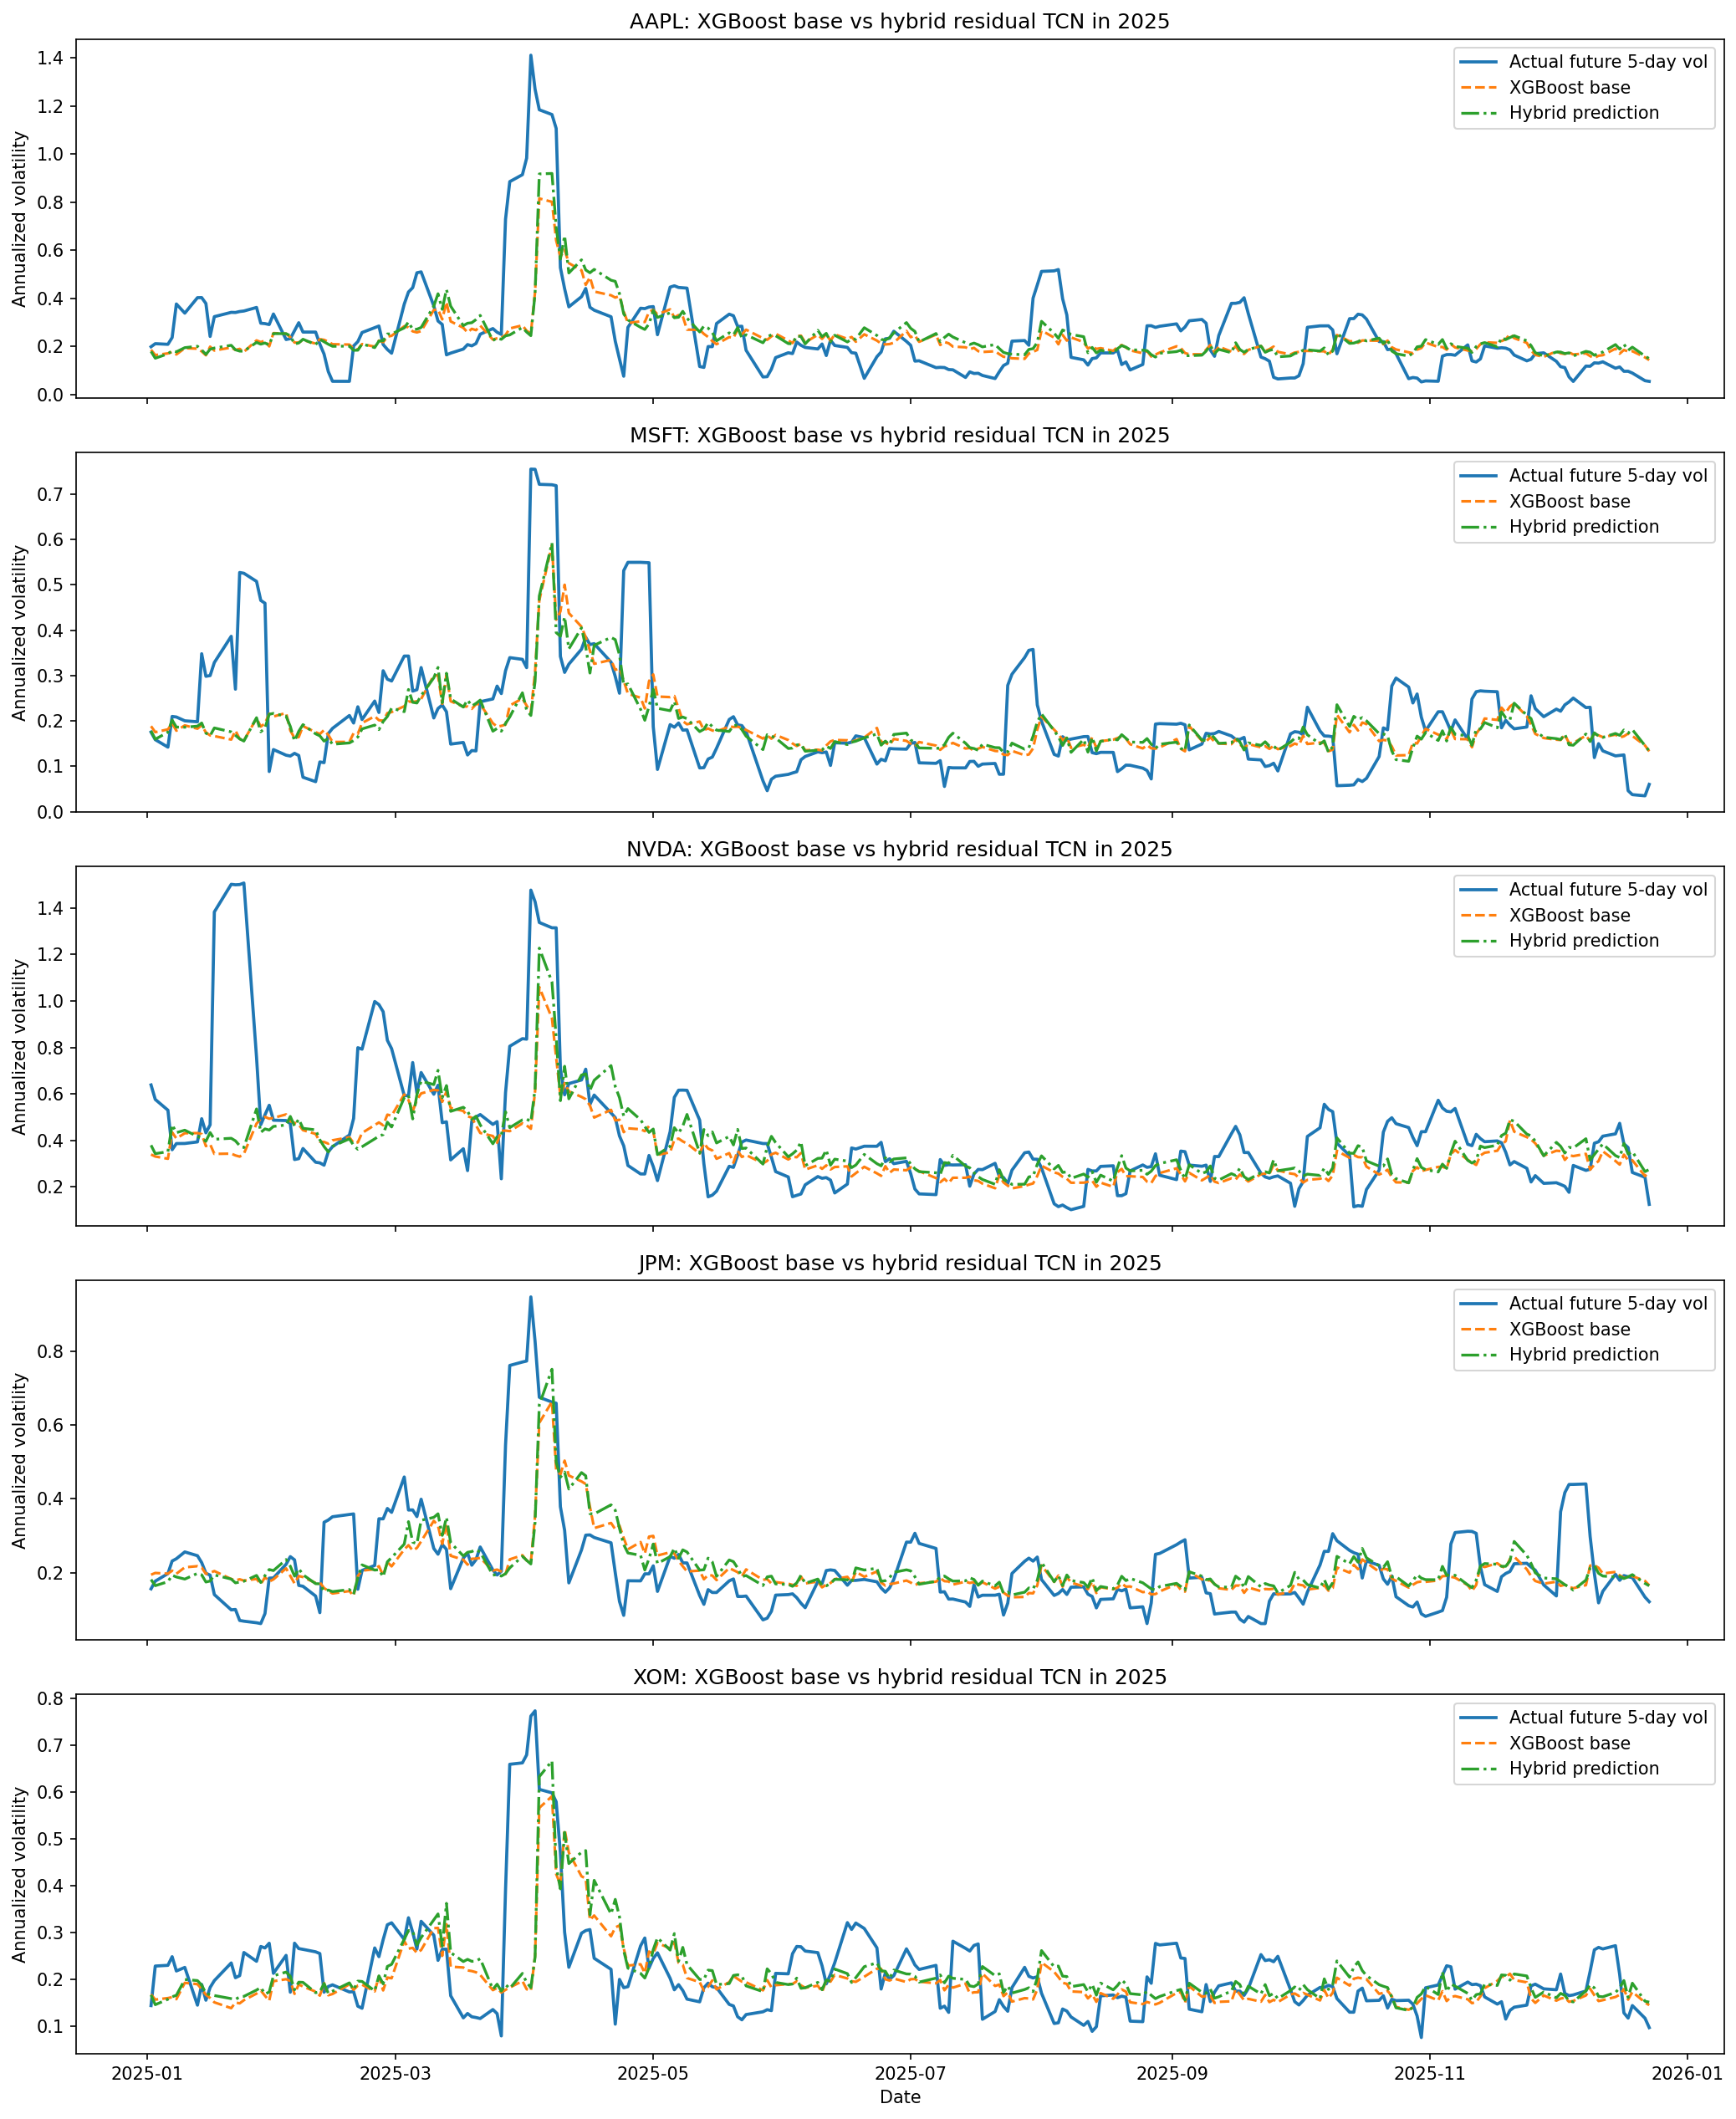

PosixPath('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project/figures/xgb_residual_tcn_5stocks.png')

In [8]:
fig, axes = plt.subplots(len(selected_tickers), 1, figsize=(14, 17), sharex=True)

for ax, ticker in zip(axes, selected_tickers):
    stock_plot_df = hybrid_predictions_df[hybrid_predictions_df['Ticker'] == ticker].sort_values('Date')
    ax.plot(stock_plot_df['Date'], stock_plot_df['fvol_5d'], label='Actual future 5-day vol', linewidth=1.8)
    ax.plot(stock_plot_df['Date'], stock_plot_df['xgb_prediction'], label='XGBoost base', linestyle='--', linewidth=1.5)
    ax.plot(stock_plot_df['Date'], stock_plot_df['prediction'], label='Hybrid prediction', linestyle='-.', linewidth=1.6)
    ax.set_title(f'{ticker}: XGBoost base vs hybrid residual TCN in 2025')
    ax.set_ylabel('Annualized volatility')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Date')
plt.tight_layout()

plot_path = FIGURE_DIR / 'xgb_residual_tcn_5stocks.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(plot_path)))

plot_path

## Interpretation guide

This hybrid is a win only if the residual TCN improves on the raw XGBoost forecast in a meaningful way, ideally without making the low-volatility bias worse.